[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skod52_example_part3.ipynb)


# Seminar

You will present findings from your notebook analysis, clearly articulating research questions, content analyses, and visualizations. Emphasis is on data storytelling and effective research communication—turning technical results into compelling, theoretically grounded insights for strategic communication.

Use no more than 1--3 clear data visualizations and focus your presentation on explaining what the figure represents and the steps taken to arrive at the figure (it might seem clear to you, but can be very challenging for the audience to understand). Finish your presentation by briefly connecting back to your research questions!


## Research Questions and Hypotheses

**RQ1. How does Equinor frame its sustainability efforts in terms of future-oriented innovation versus present-focused responsibility?**
**H1.** *Future-oriented sustainability framing will appear more frequently than responsibility framing,* operationalized through higher frequency of POS patterns (e.g., modal verbs such as *will*, *can*, *aim to*) and lexical aspects related to innovation, technology, and transition.

**RQ2. Which stakeholder groups are most prominently featured in Equinor’s sustainability communication?**
**H2.** *Governmental and community stakeholders will be referenced more frequently than end-consumers or NGOs,* operationalized using NER outputs (e.g., ORG, GPE, NORP entities) and concordances around stakeholder-related keywords (e.g., *partners*, *communities*, *authorities*, *customers*).

## NLP Data Collection

When presenting data visualizations, it can be better to hide code cells and text cells that are not directly relevant. The button to hide/show cells is show as a small arrow directly to the left of the heading. This is sometimes called "code folding".

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor'
pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

if pdf_files:
    print('PDF files in the folder:')
    for pdf in pdf_files:
        print(pdf)
else:
    print('No PDF files found in the specified folder.')

PDF files in the folder:
equinor09-energy-perspectives.pdf
equinor01-protecting-the-environment.pdf
equinor02-health-safety-and-security.pdf
equinor03-human-rights.pdf
equinor04-governance-and-transparency.pdf
equinor05-our-transition-ambitions.pdf
equinor06-a-just-energy-transition.pdf
equinor07-environmental-social-and-governance-esg-reporting-centre.pdf
equinor08-impact-assessments.pdf


In [3]:
!pip install -q PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.4 MB/s eta 0:00:00


Now, let's import the necessary libraries and define a function to extract text from a single PDF file.

In [4]:
import PyPDF2
import os

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text() + "\n"
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
    return text

Next, I will iterate through the PDF files identified earlier, extract text from each, and store them in a dictionary where the keys are the filenames and the values are the extracted texts. I'll display the first 500 characters of each extracted text to give you a preview.

In [5]:
extracted_texts = {}
# Define the directory to save text files
save_directory = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/'
save_directory = '/content/'

for pdf_file in pdf_files:
    full_pdf_path = os.path.join(folder_path, pdf_file)
    print(f"Extracting text from: {full_pdf_path}")
    text_content = extract_text_from_pdf(full_pdf_path)
    extracted_texts[pdf_file] = text_content
    #print(f"Extracted text from {pdf_file} (first 500 chars):\n{text_content[:500]}\n")

    # Save the extracted text to a .txt file
    txt_filename = os.path.splitext(pdf_file)[0] + '.txt'
    txt_filepath = os.path.join(save_directory, txt_filename)
    with open(txt_filepath, 'w', encoding='utf-8') as f:
        f.write(text_content)
    print(f"Saved extracted text to: {txt_filepath}\n")

print(f"\nSuccessfully extracted text from {len(extracted_texts)} PDF files and saved to {save_directory}.")

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor09-energy-perspectives.pdf
Saved extracted text to: /content/equinor09-energy-perspectives.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor01-protecting-the-environment.pdf
Saved extracted text to: /content/equinor01-protecting-the-environment.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor02-health-safety-and-security.pdf
Saved extracted text to: /content/equinor02-health-safety-and-security.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor03-human-rights.pdf
Saved extracted text to: /content/equinor03-human-rights.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor04-governance-and-transparency.pdf
Saved extracted text to: /content/equinor04-governance-and-transparency.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52

## NLP Data Analysis 1

Loading spaCy model...
Model loaded successfully.
Found 9 files. Reading content...
Starting text normalization with spaCy...
Normalization complete. Total processed tokens: 7366
Counting word frequencies...
Top 50 terms counted.
Saving top 50 words to wordcloud_data.tsv...
TSV file saved successfully.
Generating WordCloud figure and saving to wordcloud_figure.png...
WordCloud figure saved successfully.



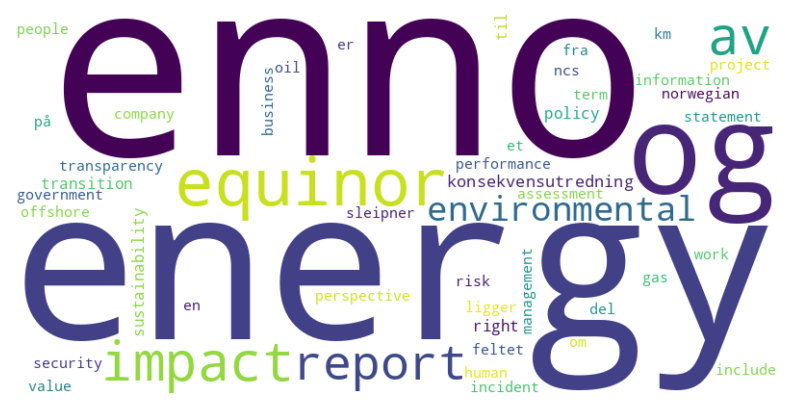

In [6]:
import glob
import os
import re
from collections import Counter

# Data Processing and Visualization Libraries
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# NLP Libraries
# Ensure you have run: pip install spacy nltk wordcloud matplotlib pandas
# And downloaded the spacy model: python -m spacy download en_core_web_sm
import spacy

# --- Configuration ---
FILE_PATH = "/content/*.txt"
N_TOP_WORDS = 50
TSV_OUTPUT_FILE = "wordcloud_data.tsv"
PNG_OUTPUT_FILE = "wordcloud_figure.png"

# Load the small English spaCy model
try:
    print("Loading spaCy model...")
    nlp = spacy.load("en_core_web_sm")
    print("Model loaded successfully.")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'.")
    # This might fail in some environments (like Colab notebooks) if run directly.
    # The user should ensure it's downloaded before running the script.
    # For a notebook environment, you'd typically run: !python -m spacy download en_core_web_sm
    raise

# --- 1. Read and Combine Text Files ---
def read_text_files(file_path_pattern):
    """Reads all text files matching the pattern and combines them into one string."""
    all_text = ""
    file_list = glob.glob(file_path_pattern)
    if not file_list:
        print(f"Warning: No files found matching pattern: {file_path_pattern}")
        # Use placeholder text for demonstration if no files are found
        # In a real environment, you might prefer to raise an exception or exit
        # This placeholder allows the rest of the code to run for demonstration purposes
        if file_path_pattern == "/content/*.txt":
            print("Using placeholder text for demonstration purposes.")
            return "This is a sample text file to demonstrate wordcloud creation. Python, programming, and spaCy are all important tools for text analysis, data science, and natural language processing. The quick brown fox jumps over the lazy dog."
        else:
            raise FileNotFoundError(f"No files found at {file_path_pattern}. Please ensure the path is correct.")

    print(f"Found {len(file_list)} files. Reading content...")
    for file_name in file_list:
        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                all_text += f.read() + " "
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
    return all_text

# --- 2. Text Normalization and Tokenization (using spaCy) ---
def normalize_and_tokenize(text, nlp_model):
    """Processes text using spaCy for normalization."""
    print("Starting text normalization with spaCy...")
    doc = nlp_model(text.lower())  # Apply lowercase at the start of spaCy processing

    # Process and filter tokens
    processed_tokens = [
        token.lemma_              # Lemmatization
        for token in doc
        if not token.is_stop      # Stop word removal
        and token.is_alpha        # Keep only alphabetic tokens (removes punctuation, numbers, etc.)
        and not token.is_space    # Remove pure whitespace tokens
        and len(token.lemma_) > 1 # Remove single-letter tokens (often noise)
    ]
    print(f"Normalization complete. Total processed tokens: {len(processed_tokens)}")
    return processed_tokens

# --- 3. Word Frequency Counting ---
def count_words(tokens, n_top):
    """Counts word frequencies and returns the top N as a DataFrame."""
    print("Counting word frequencies...")
    word_counts = Counter(tokens)
    top_words = word_counts.most_common(n_top)

    df_wordcloud = pd.DataFrame(top_words, columns=['term', 'frequency'])
    print(f"Top {n_top} terms counted.")
    return df_wordcloud

# --- 4. Main Execution ---
if __name__ == "__main__":
    combined_text = read_text_files(FILE_PATH)

    if not combined_text.strip():
        print("The combined text is empty. Cannot proceed.")
    else:
        # Normalization
        tokens = normalize_and_tokenize(combined_text, nlp)

        # Word Counting and Dataframe Creation
        df_top_words = count_words(tokens, N_TOP_WORDS)

        # 4a. Save WordCloud Data as TSV
        print(f"Saving top {N_TOP_WORDS} words to {TSV_OUTPUT_FILE}...")
        df_top_words.to_csv(TSV_OUTPUT_FILE, sep='\t', index=False)
        print("TSV file saved successfully.")

        # 4b. Generate and Save WordCloud Figure (PNG)
        if not df_top_words.empty:
            # Create a dictionary from the DataFrame for the WordCloud object
            word_freq_dict = dict(zip(df_top_words['term'], df_top_words['frequency']))

            print(f"Generating WordCloud figure and saving to {PNG_OUTPUT_FILE}...")

            # Use the WordCloud library
            wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                collocations=False, # Disable to only count single terms based on frequency
                min_font_size=10
            ).generate_from_frequencies(word_freq_dict)

            # Save the figure
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis("off")
            plt.savefig(PNG_OUTPUT_FILE, format='png')
            print("WordCloud figure saved successfully.")

            # Display a placeholder for the generated image
            print(f"")
        else:
            print("No words were processed after normalization. Cannot generate wordcloud.")


## NLP Data Visualization: Wordcloud

If we want to reduce code cells to help focus on visualizations, we can save the figure as .png file and then use minimal code to display the image. Please ensure that you prompt to update font size so that text elements are not too small.

Loading and displaying 'wordcloud_figure.png'...


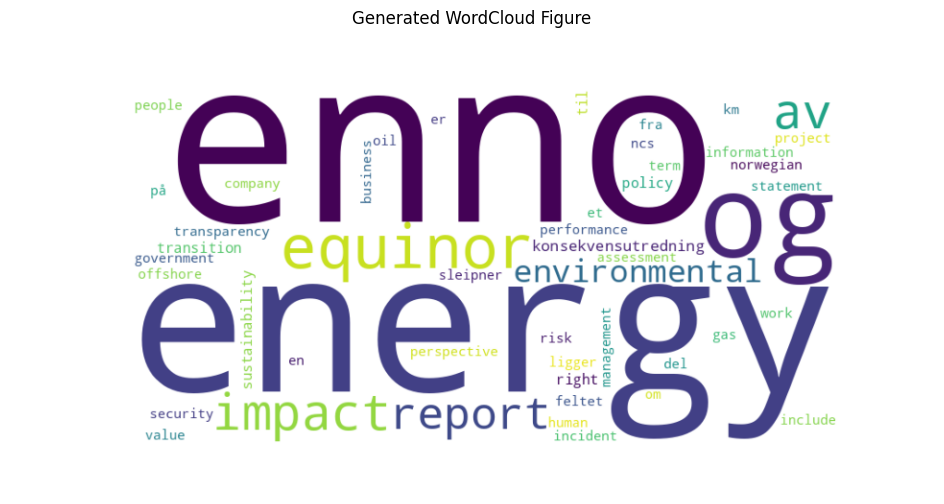

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# --- Configuration (Ensure this matches the file name used in the previous script) ---
PNG_OUTPUT_FILE = "wordcloud_figure.png"

# Check if the file exists before attempting to display it
if os.path.exists(PNG_OUTPUT_FILE):
    print(f"Loading and displaying '{PNG_OUTPUT_FILE}'...")

    # Read the image data
    img = mpimg.imread(PNG_OUTPUT_FILE)

    # Display the image using matplotlib
    plt.figure(figsize=(12, 6)) # Adjust figure size for better viewing
    plt.imshow(img)
    plt.title("Generated WordCloud Figure")
    plt.axis('off') # Hide the axis for a cleaner look
    plt.show()
else:
    print(f"Error: The file '{PNG_OUTPUT_FILE}' was not found.")
    print("Please ensure the previous code cell ran successfully and saved the file in the current working directory.")

## NLP Data Visualization: Bar plot

If we have a large figure that require a lot of display area, we can try to right-click on the figure and select "open image in new tab". Go ahead and try it with the figure below!

Bar plot saved successfully as 'word_frequency_bar_plot.png'.


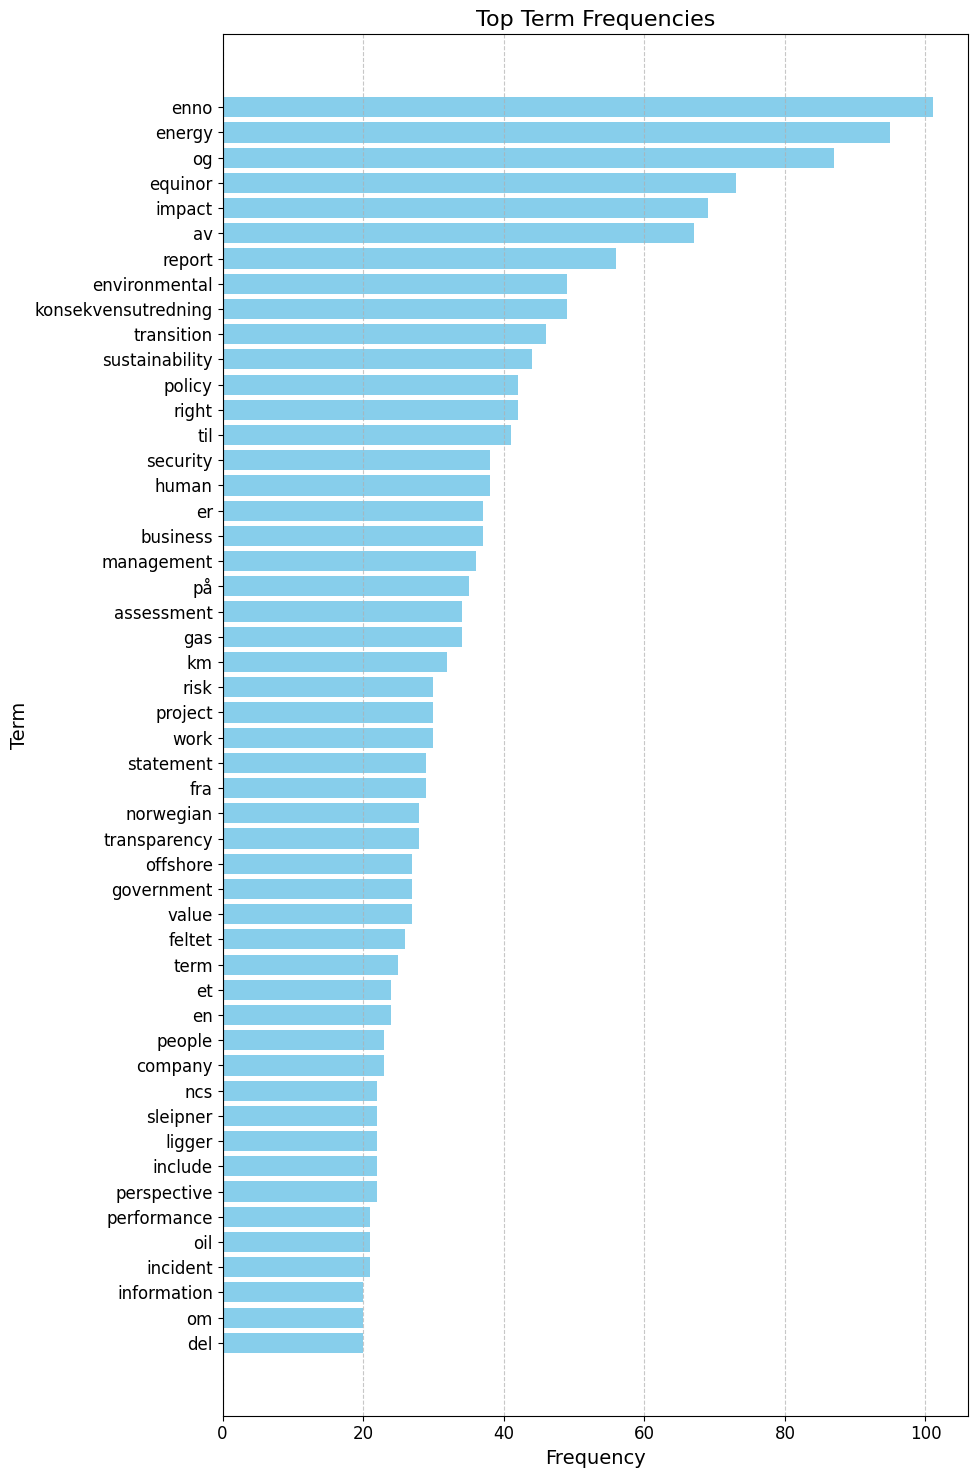

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Configuration ---
TSV_INPUT_FILE = "wordcloud_data.tsv"
PNG_OUTPUT_FILE_BAR_PLOT = "word_frequency_bar_plot.png"
INCREASED_FONT_SIZE = 14

# Check if the file exists (using the assumption it was created in the previous step)
if not os.path.exists(TSV_INPUT_FILE):
    # This block would execute if the file wasn't found in a real environment
    print(f"Error: Input file '{TSV_INPUT_FILE}' not found. Please ensure the previous wordcloud generation script ran successfully.")
else:
    try:
        # 1. Read the TSV file into a DataFrame
        df = pd.read_csv(TSV_INPUT_FILE, sep='\t')

        # 2. Setup matplotlib for increased font size
        # This updates the default font size for most text elements
        plt.rcParams.update({'font.size': INCREASED_FONT_SIZE})

        # 3. Create the horizontal bar plot
        # Using a large height for the figure ensures word labels are not overlapping
        fig, ax = plt.subplots(figsize=(10, 15))

        # Prepare data for plotting. Reverse the lists so the highest frequency bar is at the top.
        terms = df['term'].tolist()
        frequencies = df['frequency'].tolist()

        # Plotting (using barh for horizontal bars)
        ax.barh(terms[::-1], frequencies[::-1], color='skyblue')

        # Set titles and labels
        ax.set_title('Top Term Frequencies', fontsize=INCREASED_FONT_SIZE + 2)
        ax.set_xlabel('Frequency', fontsize=INCREASED_FONT_SIZE)
        ax.set_ylabel('Term', fontsize=INCREASED_FONT_SIZE)

        # Adjust tick label font size
        ax.tick_params(axis='both', which='major', labelsize=INCREASED_FONT_SIZE - 2)

        # Add a vertical grid for easier reading of frequency values
        ax.grid(axis='x', linestyle='--', alpha=0.7)

        # Adjust layout to prevent labels from being cut off
        plt.tight_layout()

        # 4. Save the figure
        plt.savefig(PNG_OUTPUT_FILE_BAR_PLOT)
        print(f"Bar plot saved successfully as '{PNG_OUTPUT_FILE_BAR_PLOT}'.")

    except Exception as e:
        print(f"An error occurred during file reading or plotting: {e}")